# Cuisine Classifier

**Name(s)**: Tanvi Vidyala, Nithya Nair

**Website Link**: https://tanvividyala.github.io/cuisine-classifier/

In [97]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import plotly.express as px
pd.options.plotting.backend = 'plotly'
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from itertools import combinations

#from dsc80_utils import * 

## Step 1: Introduction

In [2]:
interactions = pd.read_csv('RAW_interactions.csv')
recipes = pd.read_csv('RAW_recipes.csv')
combined = interactions.merge(recipes, left_on = 'recipe_id', right_on = 'id')

In [3]:
recipes['n_steps'].max()

100

In [4]:
interactions.columns

Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='object')

In [5]:
recipes.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')

## Step 2: Data Cleaning and Exploratory Data Analysis

In [6]:
pd.set_option('display.max_rows', 100)

In [7]:
for col in recipes.columns:
    print(f'{col}: {recipes[col].dtype}') 

name: object
id: int64
minutes: int64
contributor_id: int64
submitted: object
tags: object
nutrition: object
n_steps: int64
steps: object
description: object
ingredients: object
n_ingredients: int64


### Cleaning Extra Whitespace

In [8]:
recipes['name'].str.replace(r"\s{2,}", ' ', regex = True)
recipes['description'].str.replace(r"\s{2,}", ' ', regex = True)
recipes['steps'].str.replace(r"\s{2,}", ' ', regex = True)

0        ['heat the oven to 350f and arrange the rack i...
1        ['pre-heat oven the 350 degrees f', 'in a mixi...
2        ['preheat oven to 350 degrees', 'spray a 2 qua...
3        ['freheat the oven to 300 degrees', 'grease a ...
4        ['pan fry bacon , and set aside on a paper tow...
                               ...                        
83777    ['heat oil in a 4-quart dutch oven', 'add cele...
83778          ['mix all ingredients together thoroughly']
83779    ['in a bowl , combine the mashed yolks and may...
83780    ['place melted butter in a large mixing bowl a...
83781    ['whip sugar and shortening in a large bowl , ...
Name: steps, Length: 83782, dtype: object

### Average Rating for Each (Available) Recipe

In [9]:
interactions['rating'].isna().sum()

0

In [10]:
rating = interactions.groupby('recipe_id')['rating'].mean()
recipes['rating'] = rating

In [11]:
recipes['rating'].isna().sum()

54215

### Putting Nutrition into its own Columns

In [12]:
recipes['nutrition'] = recipes['nutrition'].str.replace('[', '').str.replace(']', '').str.split(',')

In [13]:
recipes['calories'] = recipes['nutrition'].apply(lambda x: float(x[0]))
recipes['total_fat'] = recipes['nutrition'].apply(lambda x: float(x[1]))
recipes['sugar'] = recipes['nutrition'].apply(lambda x: float(x[2]))
recipes['sodium'] = recipes['nutrition'].apply(lambda x: float(x[3]))
recipes['protein'] = recipes['nutrition'].apply(lambda x: float(x[4]))
recipes['saturated_fat'] = recipes['nutrition'].apply(lambda x: float(x[5]))
recipes['carbs'] = recipes['nutrition'].apply(lambda x: float(x[6]))

### Splitting Tags into a List

In [14]:
recipes['nutrition']
recipes['tags'].iloc[1]
def split_tags(tags):
    string = tags[1:len(tags)-1]
    string = string.replace("'", "")
    string_list = string.split(', ')
    return string_list

tags = recipes['tags'].apply(split_tags)
full_recipe = tags.explode()

In [15]:
full_recipe.value_counts()

tags
preparation                            83097
time-to-make                           79966
course                                 76917
main-ingredient                        56766
dietary                                49098
                                       ...  
middle-eastern-main-dish                   1
high-in-something-diabetic-friendly        1
black-bean-soup                            1
snacks-kid-friendly                        1
roast-beef-comfort-food                    1
Name: count, Length: 549, dtype: int64

In [16]:
# modified dataframe with tags in a list
mod_recipe = recipes.copy()
mod_recipe['tags'] = tags
exploded = mod_recipe['tags'].explode()

### Splitting into American and European Recipes

In [17]:
# american recipes
index = exploded[exploded == 'american'].index
american = mod_recipe.iloc[index]

# european recipes
index = exploded[exploded == 'european'].index
european = mod_recipe.iloc[index]

### Visualizations

#### Number of Ingredients

In [18]:
fig = px.histogram(recipes, x = 'n_ingredients')
fig.show()

#### Number of Steps

In [19]:
fig = px.histogram(recipes, x = 'n_steps')
fig.show()

#### Ratings of Recipes

In [20]:
fig = px.histogram(recipes, x = 'rating')
fig.show()

#### Number of Ingredients v. Number of Steps

In [21]:
# No correlation :(
fig = px.scatter(recipes, x='n_ingredients', y = 'n_steps')
fig.show()

#### Minutes to Prepare v. Number of Steps

In [22]:
fig = px.scatter(recipes, x='minutes', y = 'n_steps')
fig.show()

#### Sugar

In [49]:
recipes.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients', 'rating', 'calories', 'total_fat', 'sugar', 'sodium',
       'protein', 'saturated_fat', 'carbs'],
      dtype='object')

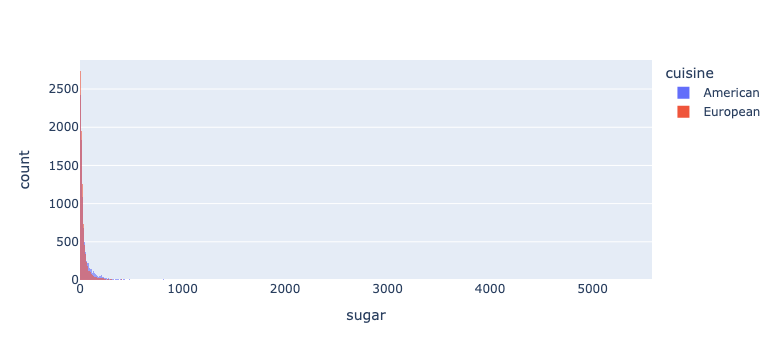

In [52]:
df_combined = pd.concat([
    american.assign(cuisine="American"),
    european.assign(cuisine="European")
])

fig = px.histogram(
    df_combined,
    x="sugar",
    color="cuisine",
    barmode="overlay",  
    opacity=0.6
)

fig.show()

## Step 3: Assessment of Missingness

In [26]:
interactions.isna().sum()

user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64

In [27]:
recipes.isna().sum()

name                  1
id                    0
minutes               0
contributor_id        0
submitted             0
tags                  0
nutrition             0
n_steps               0
steps                 0
description          70
ingredients           0
n_ingredients         0
rating            54215
calories              0
total_fat             0
sugar                 0
sodium                0
protein               0
saturated_fat         0
carbs                 0
dtype: int64

## Step 4: Hypothesis Testing

In [28]:
# TODO

## Step 5: Framing a Prediction Problem

**Prediction Problem**: How can we use the nutritional facts and ingredient lists to classify whether a recipe would be tagged as European or American? 

At the time of prediction, the nutrition information (calories, total fat, sodium, protein, saturated fat, and carbohydrates) as well as the list of ingredients in each recipe wil be known.

This problem will be **binary classification** since there are two possible classes we are predicting (American or European). Our prediction will be the `LABEL` column. We'll be evaluating our model's success using **both accuracy** and **F1-score**. Accuracy is appropriate because our classes are nearly balanced, while F1-score adds to it by accounting for precision and recall, giving a more nuanced view of model performance across both cuisine categories.

## Step 6: Baseline Model

We used a **Random Forest Classifier** for this problem because it can handle different data types well and is robust to noise while capturing nonlinear patterns in the dataset. <br> 

Our baseline model used all 7 **quantitative** nutritional variables as predictors:
`CALORIES`<br>
`TOTAL_FAT`<br>
`SUGAR`<br>
`SODIUM`<br>
`PROTEIN`<br>
`SATURATED_FAT`<br>
`CARBS`<br>

As well as one **nominal** text feature containing lists of ingredients for each recipe:<br>
`INGREDIENTS`

The `INGREDIENTS` column was turned into a quantitative variable using the built-in `TfidfVectorizer`. We also encoded the `LABELS` target column using `LabelEncoder` to turn categorical labels (American and European) into integers. 

Our model returned a F-1 Score of **0.77** for the American class and an F-1 Score of **0.76** for the European class. The model accuracy was similar at **0.7602**. This indicated somewhat strong, balanced performance across both our categories. Since both two classes are nearly evenly distributed, and that the model performs consistently across them, we believe the model is “good” for a baseline.

In [91]:
american['label'] = 'american'
european['label'] = 'european'

df = pd.concat([american, european], ignore_index=True)

df = df[['name', 'n_ingredients', 'calories', 'total_fat', 'sugar', 'sodium',
         'protein', 'saturated_fat', 'carbs', 'ingredients', 'label']]

/var/folders/ym/3kwq9dtj5914fkc699t0n4980000gn/T/ipykernel_61824/2195431788.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/ym/3kwq9dtj5914fkc699t0n4980000gn/T/ipykernel_61824/2195431788.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [94]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Transformer: join list of ingredients into a string
list_to_string = FunctionTransformer(lambda x: x.apply(lambda lst: " ".join(lst)))

# 1. Define Feature Sets
numeric_features = ['total_fat', 'calories', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbs']
text_features = ['ingredients']   # still use ingredients but now handled correctly
target = 'label'

# 2. Prepare X, y
X = df[numeric_features + text_features]
y = df[target]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('ing_tfidf', TfidfVectorizer(max_features=3000, stop_words='english'), 'ingredients'),
    ],
    remainder='drop'
)

# 5. Build Pipeline with Random Forest
rf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
    ))
])

# 6. Train Model
rf_pipeline.fit(X_train, y_train)

# 7. Evaluate Model
y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7620490223079042

Classification Report:

              precision    recall  f1-score   support

    american       0.76      0.77      0.77      1852
    european       0.76      0.75      0.76      1779

    accuracy                           0.76      3631
   macro avg       0.76      0.76      0.76      3631
weighted avg       0.76      0.76      0.76      3631



## Step 7: Final Model
Firstly, we wanted to assess which combination of our initial 7 quantitative features would result in an optimal accuracy rate. To assess this, we tested all 26 possible combinations of our features to understand which variables held the strongest signal for distinguishing American and European recipes.

#### Top 10 Feature Combinations
| Rank | Feature Combination                          | Accuracy     |
| ---- | -------------------------------------------- | ------------ |
| 1    | sugar, sodium, protein, saturated_fat, carbs | **0.763701** |
| 2    | protein, saturated_fat                       | 0.762875     |
| 3    | sodium, protein                              | 0.762324     |
| 4    | sugar, protein, carbs                        | 0.762049     |
| 5    | sugar, sodium, protein, carbs                | 0.761498     |
| 6    | sodium, protein, saturated_fat, carbs        | 0.761223     |
| 7    | saturated_fat, carbs                         | 0.761223     |
| 8    | protein, carbs                               | 0.760947     |
| 9    | sugar, protein, saturated_fat, carbs         | 0.760397     |
| 10   | sugar, sodium, protein, saturated_fat        | 0.760397     |

Across all subsets, we found that the combination of `SUGAR`, `SODIUM`, `PROTEIN`, `SATURATED_FAT`, and `CARBS` was the most effective combination of unmodified features. This lead us to drop `CALORIES` and `TOTAL_FAT`. `CALORIES` did not meaningfully distinguish the cuisines since it is an aggregate measure, and `TOTAL_FAT` is largely multicollinear with saturated fat, which already captures the more relevant nutritional signal.

Next, we used a 5-fold Grid Search to find the optimal hyperparameters for our Random Forest Classification model. We assessed various values for `max_depth`, `min_samples_split`, and `criterion`. 

```python
hyperparameters = {
    'max_depth': [2, 25, 50, 75, 100, 125, 150, 175, 200, None],
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'criterion': ['gini', 'entropy']
}
```

The best hyperparameters returned by Grid Search was **Entropy** for `criterion`, **100** for `max-depth`, and **100** for `min_samples_split`.

Lastly, we engineered two new features `PROTEIN_DENSITY` and `FAT_PROTEIN_RATIO` to add to the model. 

`PROTEIN_DENSITY` highlights how much protein a recipe provides relative to its calories, capturing differences in macronutrient balance between cuisines that raw protein alone cannot.

`FAT_PROTEIN_RATIO` measures saturated fat relative to protein, reflecting contrasts in cooking styles—such as dairy-based fats in European dishes versus protein-heavy American recipes—and reveals patterns not visible in either nutrient alone.

In the end, the performance of the final model on the training data achieved a F-1 score of **0.78** for the American class and an F-1 Score of **0.77** for the European class on the test data. This was a slight improvement from the baseline which was 0.77 for the American class and 0.76 for the European class. The overall model accuracy improved as well increasing from 0.762 with the baseline model to **0.773**.

### Assessing Feature Combinations

In [104]:
numeric_features = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbs']
text_features = ['ingredients']
target = 'label'

X = df[numeric_features + text_features]
y = df[target]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

results = {}

for r in range(2, 6): 
    for combo in combinations(numeric_features, r):

        preprocess = ColumnTransformer(
            transformers=[
                ('num', 'passthrough', list(combo)),
                ('ing_tfidf', TfidfVectorizer(max_features=3000, stop_words='english'), 'ingredients'),
            ],
            remainder='drop'
        )

        rf_pipeline = Pipeline([
            ('preprocess', preprocess),
            ('classifier', RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                random_state=42,
            ))
        ])

        rf_pipeline.fit(X_train, y_train)

        y_pred = rf_pipeline.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        combo_name = ", ".join(combo)
        results[combo_name] = acc

results_series = pd.Series(results).sort_values(ascending=False)

print(results_series)

KeyboardInterrupt: 

### Using Grid Search to Find Optimal Hyperparameters

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
hyperparameters = {
    'classifier__max_depth': [2, 25, 50, 75, 100, 125, 150, 175, 200, None], 
    'classifier__min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'classifier__criterion': ['gini', 'entropy']
}

searcher = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=hyperparameters,
    cv=5,
    verbose=3
)
searcher.fit(X_train, y_train)
searcher.best_params_

Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV 1/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=2;, score=0.700 total time=   1.0s
[CV 2/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=2;, score=0.680 total time=   1.0s
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=2;, score=0.684 total time=   1.0s
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=2;, score=0.659 total time=   1.0s
[CV 5/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=2;, score=0.675 total time=   1.0s
[CV 1/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=5;, score=0.700 total time=   1.0s
[CV 2/5] END classifier__criterion=gini, classifier__max_depth=2, classifier__min_samples_split=5;, score=0.680 total time=   1.0s
[CV 3/5] END classif

{'classifier__criterion': 'entropy',
 'classifier__max_depth': 100,
 'classifier__min_samples_split': 100}

### Final Model (with Transformed Data)

In [103]:
df['protein_density'] = df['protein'] / (df['calories'] + 1)
df['fat_protein_ratio'] = df['saturated_fat'] / (df['protein'] + 1)

# 1. Define Feature Sets
numeric_features = ['sugar', 'sodium', 'saturated_fat', 'carbs', 'protein_density', 'fat_protein_ratio']
text_features = ['ingredients']
target = 'label'

# 2. Prepare X, y
X = df[numeric_features + text_features]
y = df[target]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('ing_tfidf', TfidfVectorizer(max_features=3000, stop_words='english'), 'ingredients'),
    ],
    remainder='drop'
)

# 5. Build Pipeline with Random Forest
rf_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=100,
        max_depth=100,
        criterion='entropy',
        random_state=42,
    ))
])

# 6. Train Model
rf_pipeline.fit(X_train, y_train)

# 7. Evaluate Model
y_pred = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7730652712751308

Classification Report:

              precision    recall  f1-score   support

    american       0.77      0.79      0.78      1852
    european       0.77      0.76      0.77      1779

    accuracy                           0.77      3631
   macro avg       0.77      0.77      0.77      3631
weighted avg       0.77      0.77      0.77      3631



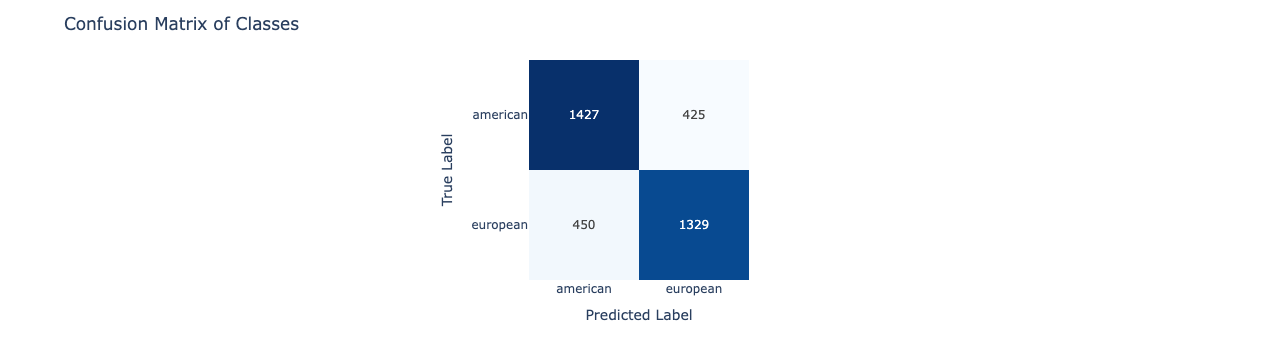

In [121]:
from sklearn.metrics import confusion_matrix
import plotly.express as px

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_ 

# Create a Plotly heatmap
fig = px.imshow(
    cm,
    text_auto=True,
    x=labels,
    y=labels,
    color_continuous_scale="Blues",
    labels=dict(x="Predicted Label", y="True Label", color="Count")
)

fig.update_layout(
    title="Confusion Matrix of Classes",
    xaxis=dict(side="bottom"),
    coloraxis_showscale=False,
    width = 1000
)

fig.show()

fig.write_html('confusion-matrix.html', include_plotlyjs='cdn')

## Step 8: Fairness Analysis

To assess the fairness of our final model, we decided to evaluate whether the recall score is significantly different across both cuisine groups, American and European. 

- **Group X**: Recipes classified as American
- **Group Y**: Recipes classified as European
- **Evaluation Metric**: Recall
- **Null**: Our model is fair. There is no significant difference in recall for the American and European cuisine classes, and any differences are due to random chance.
- **Alternative**: Our model is unfair. There is a significant difference in recall for the American and European cuisine classes.
- **Test Statistic**: Calculated Difference in Recall (~0.0256)
- **Significance Level**: α = 0.05
- **P-Value**: 1.0

Since our p-value of 1.0 is greater than the significance level of 0.05, we fail to reject the null hypothesis, and we did not find evidence to support that our model treats American and European recipes differently.


In [112]:
from sklearn.metrics import recall_score

# true labels and predictions already computed
american_recall = recall_score(y_test, y_pred, pos_label=le.transform(['american'])[0])
european_recall = recall_score(y_test, y_pred, pos_label=le.transform(['european'])[0])

obs_stat = american_recall - european_recall
obs_stat


0.02346945465273398

In [113]:
import numpy as np

n_permutations = 5000
stats = []

y_test_array = np.array(y_test)

for _ in range(n_permutations):
    shuffled = np.random.permutation(y_test_array)
    
    # compute recall for shuffled groups
    american_recall_perm = recall_score(shuffled, y_pred, pos_label=le.transform(['american'])[0])
    european_recall_perm = recall_score(shuffled, y_pred, pos_label=le.transform(['european'])[0])

    stats.append(american_recall_perm - european_recall_perm)

stats = np.array(stats)

p_value = np.mean(stats >= obs_stat)
p_value


1.0

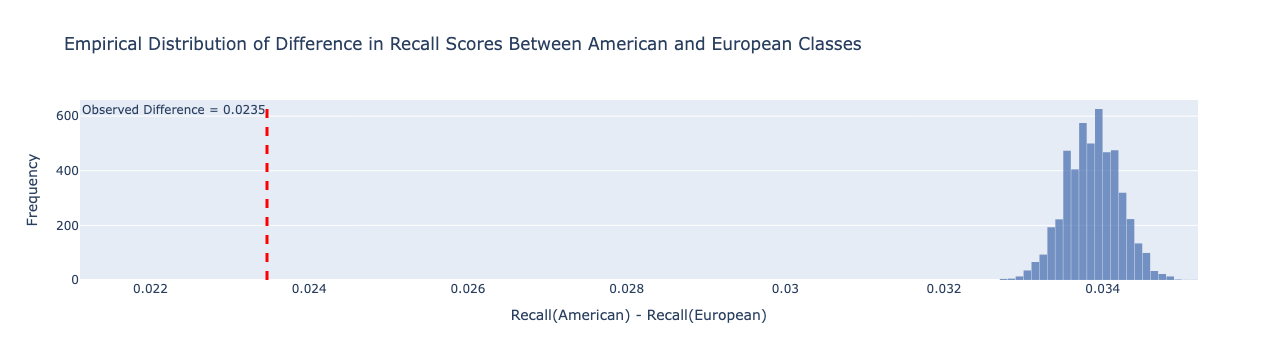

In [123]:
import plotly.express as px
import plotly.graph_objects as go

# Create histogram of permutation statistics
fig = px.histogram(
    stats,
    nbins=40,
    opacity=0.75,
    labels={'value': 'Permutation Recall Difference'},
    title='Empirical Distribution of Difference in Recall Scores Between American and European Classes',
    color_discrete_sequence=['#4C72B0']
)

# Add vertical line for observed statistic
fig.add_vline(
    x=obs_stat,
    line_width=3,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Observed Difference = {obs_stat:.4f}",
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Recall(American) - Recall(European)",
    yaxis_title="Frequency",
    showlegend=False,
    bargap=0.05,
)

fig.show()

fig.write_html('fairness-analysis.html', include_plotlyjs='cdn')